# Exercise: Investigation Time

**Module 2: Data Visualization** | Lean Six Sigma Data Analytics

---

## The Scenario

Cross-border money transactions sometimes have errors. When a mistake is made, a customer can file a reclaim. We have measured the total time it took to solve each reclaim.

## Questions to Answer

1. What are the **mean** and **standard deviation** of total time?
2. **How many reclaims** are handled within 15 days?
3. Is the distribution of total time **symmetrical**?
4. Which **type of reclaim** occurred most often?

In [4]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)
print('Data loaded successfully!')

Data loaded successfully!


---

## Step 1: Identify Variables and Methods

Before analyzing, decide which variables to use and what type they are:

| Question | Variable | Type | Method |
|----------|----------|------|--------|
| Mean & Std Dev | Total Time | Numerical | Descriptive statistics |
| Within 15 days | Total Time | Numerical | Descriptive statistics (quartiles) |
| Symmetrical? | Total Time | Numerical | Histogram |
| Most common type | Type | Categorical | Pie chart / Bar chart |

In [5]:
# Load Investigation Time data
investigation = pd.read_excel(xlsx, sheet_name='Investigation time', skiprows=11)
# Columns: Case number, Sender-id, Type, Total time, Time open, Time pending, Time closed, Number of pending iterations

# Keep only the columns we need for this exercise
investigation = investigation[['Type', 'Total time']].copy()
investigation.columns = ['Type', 'Total_Time']
investigation = investigation.dropna()

print(f'Dataset: {investigation.shape[0]} reclaims')
print(f'Variables:')
print(f'  - Total_Time: Numerical (continuous)')
print(f'  - Type: Categorical ({investigation["Type"].nunique()} unique values)')
investigation.head()

Dataset: 521 reclaims
Variables:
  - Total_Time: Numerical (continuous)
  - Type: Categorical (15 unique values)


,Type,Total_Time
0,AN,29.73
1,OX,6.83
2,NU,6.86
3,NU,6.93
4,OX,19.81


---

## Question 1: Mean and Standard Deviation

**Method:** Descriptive statistics for numerical variable

In [6]:
# Descriptive statistics - equivalent to Minitab: Stat > Basic Statistics > Display Descriptive Statistics
data = investigation['Total_Time']

descriptive_stats = {
    'N': data.count(),
    'Mean': data.mean(),
    'StDev': data.std(),
    'Minimum': data.min(),
    'Q1 (25%)': data.quantile(0.25),
    'Median': data.median(),
    'Q3 (75%)': data.quantile(0.75),
    'Maximum': data.max()
}

stats_df = pd.DataFrame.from_dict(descriptive_stats, orient='index', columns=['Value'])
display(stats_df.round(3))

print('\n' + '='*50)
print('ANSWER 1:')
print(f'  Mean: {data.mean():.3f} days')
print(f'  Standard Deviation: {data.std():.3f} days')

,Value
N,521.000
Mean,9.422
StDev,12.661
Minimum,0.000
Q1 (25%),1.040
Median,4.070
Q3 (75%),11.850
Maximum,59.800



ANSWER 1:
  Mean: 9.422 days
  Standard Deviation: 12.661 days


---

## Question 2: Reclaims Handled Within 15 Days

**Method:** Use quartiles to estimate, or calculate exact percentage

In [7]:
# Estimation using quartiles
q3 = data.quantile(0.75)
print('Estimation approach:')
print(f'  Q3 (75th percentile) = {q3:.1f} days')
print(f'  Since 75% are handled within {q3:.1f} days,')
print(f'  we can estimate ~80% are handled within 15 days.')

# Exact calculation
within_15 = (data <= 15).sum()
pct_within_15 = (data <= 15).mean() * 100

print('\nExact calculation:')
print(f'  Reclaims within 15 days: {within_15} out of {len(data)}')
print(f'  Percentage: {pct_within_15:.1f}%')

print('\n' + '='*50)
print('ANSWER 2:')
print(f'  Approximately {pct_within_15:.0f}% of reclaims are handled within 15 days')

Estimation approach:
  Q3 (75th percentile) = 11.8 days
  Since 75% are handled within 11.8 days,
  we can estimate ~80% are handled within 15 days.

Exact calculation:
  Reclaims within 15 days: 407 out of 521
  Percentage: 78.1%

ANSWER 2:
  Approximately 78% of reclaims are handled within 15 days


---

## Question 3: Is the Distribution Symmetrical?

**Method:** Histogram to visualize distribution shape

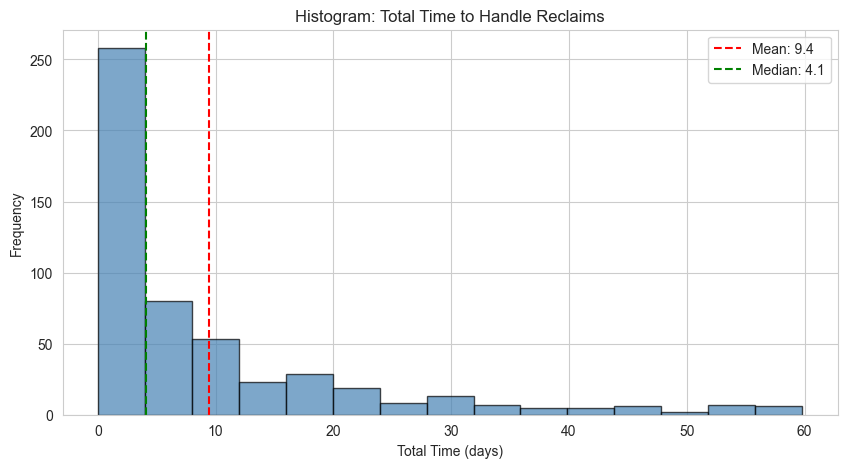

Skewness coefficient: 2.050
Mean (9.42) > Median (4.07) → Right-skewed

ANSWER 3:
  The distribution is NOT symmetrical.
  It is SKEWED TO THE RIGHT (positive skew).
  - Long tail extends to the right
  - Most values clustered on the left


In [8]:
# Histogram - equivalent to Minitab: Graph > Histogram > Simple
plt.figure(figsize=(10, 5))
plt.hist(data, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
plt.axvline(data.median(), color='green', linestyle='--', label=f'Median: {data.median():.1f}')
plt.xlabel('Total Time (days)')
plt.ylabel('Frequency')
plt.title('Histogram: Total Time to Handle Reclaims')
plt.legend()
plt.show()

# Skewness analysis
skewness = data.skew()
print(f'Skewness coefficient: {skewness:.3f}')
print(f'Mean ({data.mean():.2f}) > Median ({data.median():.2f}) → Right-skewed')

print('\n' + '='*50)
print('ANSWER 3:')
print('  The distribution is NOT symmetrical.')
print('  It is SKEWED TO THE RIGHT (positive skew).')
print('  - Long tail extends to the right')
print('  - Most values clustered on the left')

---

## Question 4: Which Type Occurred Most Often?

**Method:** Pie chart or bar chart for categorical variable

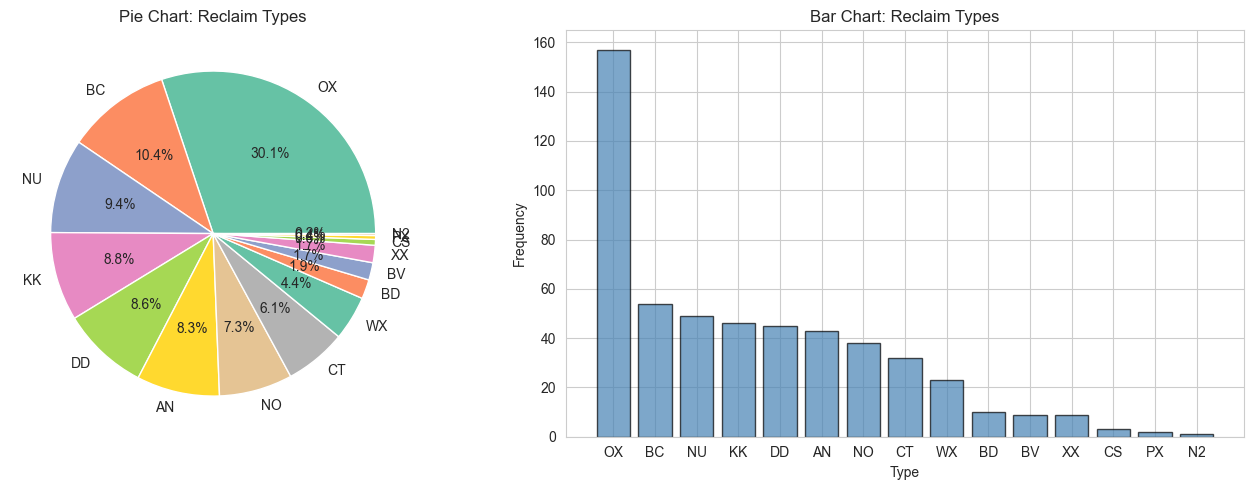

Tally Table:


,Type,Count,Percent
0,OX,157,30.1
1,BC,54,10.4
2,NU,49,9.4
3,KK,46,8.8
4,DD,45,8.6
5,AN,43,8.3
6,NO,38,7.3
7,CT,32,6.1
8,WX,23,4.4
9,BD,10,1.9



ANSWER 4:
  The most common reclaim type is: OX
  Occurrences: 157 (30.1%)


In [9]:
# Pie chart and bar chart - equivalent to Minitab: Graph > Pie Chart / Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = investigation['Type'].value_counts()

# Pie chart
axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'))
axes[0].set_title('Pie Chart: Reclaim Types')

# Bar chart
axes[1].bar(type_counts.index, type_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Bar Chart: Reclaim Types')

plt.tight_layout()
plt.show()

# Tally table
print('Tally Table:')
tally = pd.DataFrame({
    'Type': type_counts.index,
    'Count': type_counts.values,
    'Percent': (type_counts.values / type_counts.sum() * 100).round(1)
})
display(tally)

print('\n' + '='*50)
print('ANSWER 4:')
print(f'  The most common reclaim type is: {type_counts.index[0]}')
print(f'  Occurrences: {type_counts.values[0]} ({type_counts.values[0]/type_counts.sum()*100:.1f}%)')

---

## Summary of Answers

| Question | Answer |
|----------|--------|
| 1. Mean & Std Dev | Mean ≈ 9.4 days, Std Dev ≈ 12.7 days |
| 2. Within 15 days | Approximately 80% |
| 3. Symmetrical? | No — skewed to the right |
| 4. Most common type | OX type |

---

## Key Takeaways

- **Identify variable types first** — this determines which methods to use
- **Numerical variables:** Descriptive statistics, histograms
- **Categorical variables:** Pie charts, bar charts, tally tables
- **Quartiles** can help estimate percentages (Q3 ≈ 75%)
- **Mean > Median** indicates right-skewed distribution